In [133]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from copy import deepcopy

**Integração dos indicadores: Média Móvel Simples (SMA – Simple Moving Average)média aritmética dos preços de fechamento de um ativo durante um determinado período**.


**Média Móvel Exponencial (EMA – Exponential Moving Average) A EMA dá mais peso aos dados recentes, tornando-a mais sensível a mudanças recentes nos preços**

**Índice de Força Relativa (RSI – Relative Strength Index) oscilador que mede a velocidade e a mudança dos movimentos de preço**

In [134]:
def add_indicators(df, col, window=14):

    df[f'SMA_{window}'] = df[col].rolling(window).mean()
    df[f'EMA_{window}'] = df[col].ewm(span=window, adjust=False).mean()

    delta = df[col].diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)

    avg_gain = gain.rolling(window).mean()
    avg_loss = loss.rolling(window).mean()

    rs = avg_gain / avg_loss
    df[f'RSI_{window}'] = 100 - (100/(1+rs))

    return df

In [135]:
tickers = ["AAPL","MSFT","NVDA","AMZN","GOOGL","META","AVGO"]

In [136]:
target_stock = "META"   ##### <<<< MUDE AQUI A AÇÃO <<<<
print("Target stock:", target_stock)

Target stock: META


In [137]:
dfs = []

In [138]:
for t in tickers:

    df = yf.download(t, start="2015-01-01", end="2025-01-01")
    #PANDEMIA
    df = df[(df.index.year != 2020) & (df.index.year != 2021)]

    df = df[['Close']].rename(columns={'Close':f'{t}_Close'})
    df = add_indicators(df, col=f'{t}_Close')
    dfs.append(df)

/tmp/ipykernel_666/199586046.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(t, start="2015-01-01", end="2025-01-01")
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_666/199586046.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(t, start="2015-01-01", end="2025-01-01")
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_666/199586046.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(t, start="2015-01-01", end="2025-01-01")
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_666/199586046.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(t, start="2015-01-01", end="2025-01-01")
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_666/199586046.py:

In [139]:
data = pd.concat(dfs, axis=1).dropna()
target_column = f"{target_stock}_Close"

In [140]:
# Separa X e y
y = data[[target_column]].values
X = data.drop(columns=[target_column]).values

**Normalização para prepar os dados para a LSTM**

In [141]:
# Normalização
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()
X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y)

# sequências para entrada na LSTM
def create_sequences(X, y, seq_len):
    Xs, ys = [], []

    for i in range(seq_len, len(X)):
        Xs.append(X[i-seq_len:i])
        ys.append(y[i])
    return np.array(Xs), np.array(ys)

seq_len = 60
X_seq, y_seq = create_sequences(X_scaled, y_scaled, seq_len)

In [142]:
# treino/teste
split = int(0.8 * len(X_seq))
X_train, X_test = X_seq[:split], X_seq[split:]
y_train, y_test = y_seq[:split], y_seq[split:]

In [143]:
class TimeSeriesDataset(Dataset):

    def __init__(self, X, y):

        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [144]:
train_ds = TimeSeriesDataset(X_train, y_train)
test_ds = TimeSeriesDataset(X_test, y_test)
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=32)

**Uma camada LSTM seguida de uma GRU para capturar padrões temporais que tenha múltiplas variáveis, com um trecho de GRU que é bom para evitar overfitting**

In [145]:
# modelo LSTM + GRU
class LSTM_GRU_Model(nn.Module):

    def __init__(self, input_size):
        super().__init__()
        #LSTM aprende padrões de longo prazo
        self.lstm = nn.LSTM(input_size, 64, batch_first=True)
        #GRU refina as representações aprendidas pela LSTM
        self.gru = nn.GRU(64, 32, batch_first=True)
        #Camada final transforma GRU em uma predição
        self.fc = nn.Linear(32, 1)

    def forward(self, x):
        out_lstm,_ = self.lstm(x)
        out_gru,_ = self.gru(out_lstm)
        out = self.fc(out_gru[:,-1,:])

        return out

In [146]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = LSTM_GRU_Model(X_train.shape[2]).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [147]:
# treinamento
best_val_loss = float('inf')
best_model_state = None

train_losses=[]
val_losses=[]

for epoch in range(1,51):
    model.train()
    batch_losses=[]
    for xb,yb in train_loader:
        xb,yb = xb.to(device),yb.to(device)
        optimizer.zero_grad()
        preds = model(xb).squeeze()
        loss = criterion(preds,yb.squeeze())
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())
    train_loss = np.mean(batch_losses)

    model.eval()

    val_batch_losses=[]

    with torch.no_grad():
        for xb,yb in test_loader:
            xb,yb = xb.to(device),yb.to(device)
            preds = model(xb).squeeze()
            val_loss = criterion(preds,yb.squeeze())
            val_batch_losses.append(val_loss.item())
    val_loss = np.mean(val_batch_losses)
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch {epoch}: Train={train_loss:.6f} Val={val_loss:.6f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = deepcopy(model.state_dict())

Epoch 1: Train=0.002444 Val=0.077141
Epoch 2: Train=0.000980 Val=0.002818
Epoch 3: Train=0.000504 Val=0.012271
Epoch 4: Train=0.000449 Val=0.005292
Epoch 5: Train=0.000351 Val=0.006865
Epoch 6: Train=0.000292 Val=0.005041
Epoch 7: Train=0.000327 Val=0.001540
Epoch 8: Train=0.000352 Val=0.001405
Epoch 9: Train=0.000248 Val=0.003070
Epoch 10: Train=0.000267 Val=0.001209
Epoch 11: Train=0.000250 Val=0.001241
Epoch 12: Train=0.000223 Val=0.002783
Epoch 13: Train=0.000235 Val=0.000927
Epoch 14: Train=0.000215 Val=0.000954
Epoch 15: Train=0.000188 Val=0.000952
Epoch 16: Train=0.000225 Val=0.003806
Epoch 17: Train=0.000190 Val=0.001326
Epoch 18: Train=0.000179 Val=0.000929
Epoch 19: Train=0.000219 Val=0.003871
Epoch 20: Train=0.000192 Val=0.000969
Epoch 21: Train=0.000161 Val=0.002866
Epoch 22: Train=0.000181 Val=0.004587
Epoch 23: Train=0.000177 Val=0.009042
Epoch 24: Train=0.000217 Val=0.002083
Epoch 25: Train=0.000156 Val=0.003545
Epoch 26: Train=0.000162 Val=0.008339
Epoch 27: Train=0.000

In [148]:
model.load_state_dict(best_model_state)

<All keys matched successfully>

In [149]:
#predição teste
preds=[]

In [150]:
model.eval()

LSTM_GRU_Model(
  (lstm): LSTM(27, 64, batch_first=True)
  (gru): GRU(64, 32, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)

In [151]:
with torch.no_grad():
    for xb,yb in test_loader:
        xb = xb.to(device)
        out = model(xb)
        preds.extend(out.cpu().numpy())
preds = np.array(preds)
pred_prices = scaler_y.inverse_transform(preds)
real_prices = scaler_y.inverse_transform(y_test)

**o quão bem o modelo conseguiu aprender o comportamento histórico da ação**

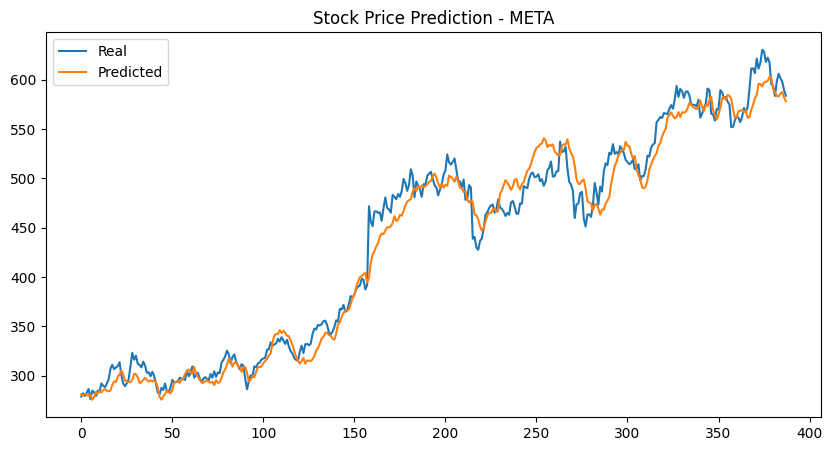

In [152]:
# plot previsão
plt.figure(figsize=(10,5))
plt.plot(real_prices,label="Real")
plt.plot(pred_prices,label="Predicted")
plt.legend()
plt.title(f"Stock Price Prediction - {target_stock}")
plt.show()

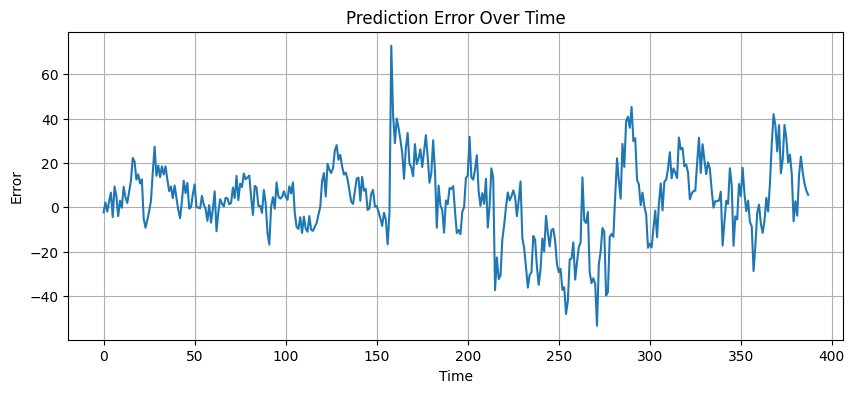

In [153]:
# plot o quão o modelo errou
errors = real_prices.flatten() - pred_prices.flatten()
plt.figure(figsize=(10,4))
plt.plot(errors)
plt.title("Prediction Error Over Time")
plt.xlabel("Time")
plt.ylabel("Error")
plt.grid(True)
plt.show()

**avaliação do processo de aprendizado**

**Train Loss → erro nos dados de treino**

**Validation Loss → erro nos dados de teste**

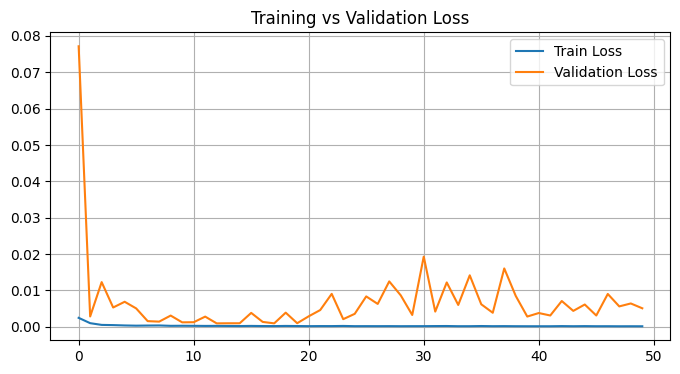

In [154]:
# plot loss
plt.figure(figsize=(8,4))
plt.plot(train_losses,label="Train Loss")
plt.plot(val_losses,label="Validation Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

**tendência esperada da ação no curto prazo (7 dias)**

In [155]:
# previsão futura
model.eval()
n_future = 7
last_sequence = X_scaled[-seq_len:]
future_preds=[]
current_input = torch.tensor(last_sequence,dtype=torch.float32).unsqueeze(0).to(device)
for _ in range(n_future):
    with torch.no_grad():
        next_pred = model(current_input)
        pred_val = next_pred.cpu().numpy()[0,0]
        future_preds.append(pred_val)
    next_step = current_input[0,-1,:].cpu().numpy()
    next_sequence = np.vstack([current_input[0,1:].cpu(),next_step])
    current_input = torch.tensor(next_sequence,dtype=torch.float32).unsqueeze(0).to(device)
future_prices = scaler_y.inverse_transform(np.array(future_preds).reshape(-1,1))

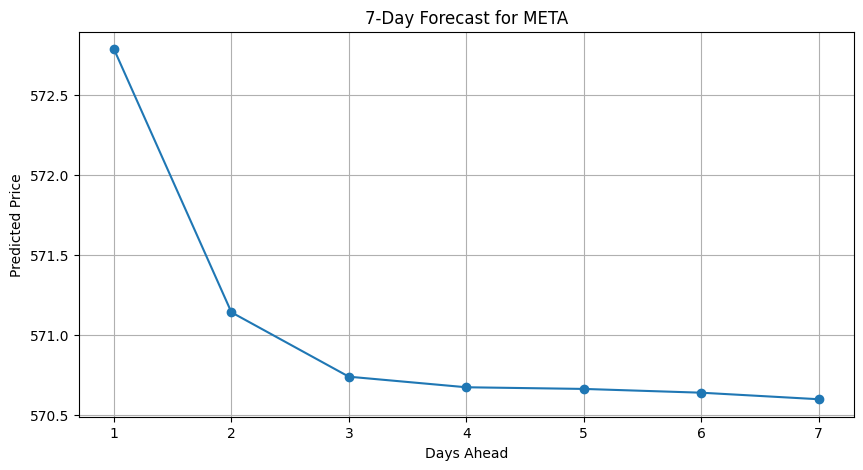

In [156]:
# plot previsão futura
plt.figure(figsize=(10,5))
plt.plot(range(1,n_future+1), future_prices, marker='o')
plt.title(f"7-Day Forecast for {target_stock}")
plt.xlabel("Days Ahead")
plt.ylabel("Predicted Price")
plt.grid(True)
plt.show()

In [157]:
print("\nPrevisão futura:")
for i,p in enumerate(future_prices):
    print(f"Dia +{i+1}: ${p[0]:.2f}")


Previsão futura:
Dia +1: $572.78
Dia +2: $571.14
Dia +3: $570.74
Dia +4: $570.67
Dia +5: $570.66
Dia +6: $570.64
Dia +7: $570.60
